In [1]:
"""
Этап 0. Подготовка
Есть ячейка с импортами и фиксированным seed = 42.
Датасет WikiText-2 загружен.

"""
import torch
import random
import pandas as pd
import re
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch.nn as nn
import torch.optim as optim
import math
import time
from torch.optim import AdamW

random.seed(42)
torch.manual_seed(42)

dataset = load_dataset("wikitext", "wikitext-2-raw-v1")


c:\Users\nerzz\first-module\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Примеры текстов в обучающей выборке:
senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
the game began development in 2010 carrying over a large portion of the work done on valkyria chronicles ii while it retained the standard features of the series it also underwent multiple adjustments such as making the game more forgiving for series newcomers character designer raita honjou and composer hitoshi s

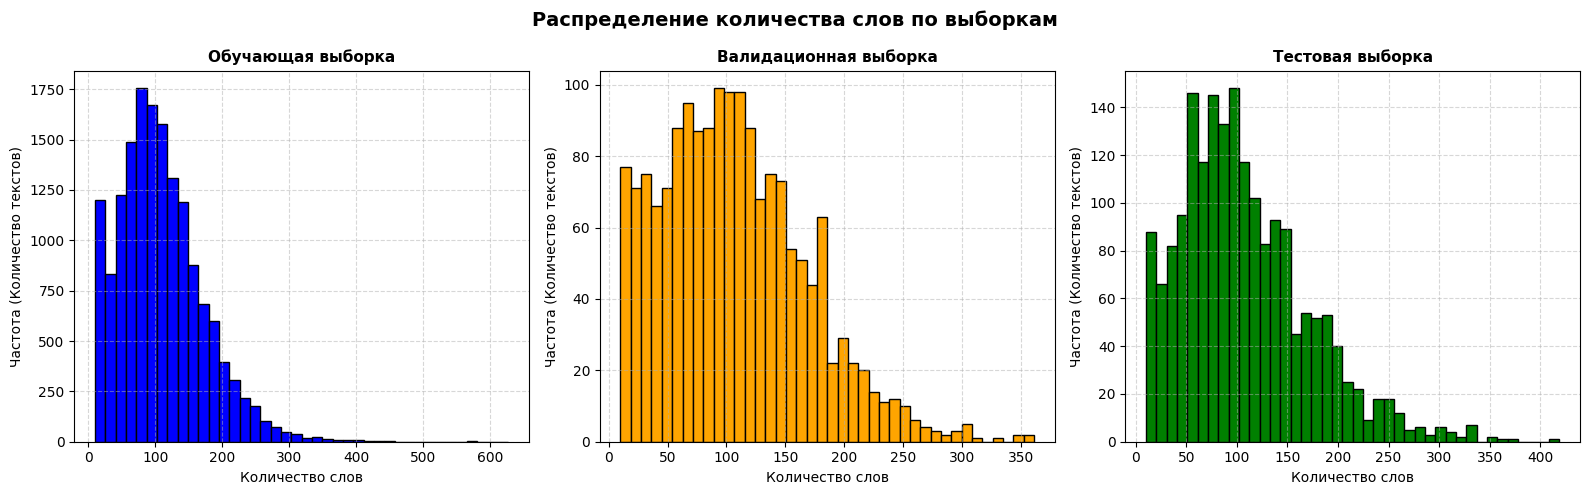

In [2]:
"""
Этап 1. Данные
1) Проведён разведочный анализ (примеры текстов, статистики (число предложений, среднюю длину, распределение длин), визуализации).

"""

# функция для "чистки" текстов
def clean_string(text):
    # приведение к нижнему регистру
    text = text.lower()
    # удаление всего, кроме латинских букв, цифр и пробелов
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # удаление дублирующихся пробелов, удаление пробелов по краям
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# функция для предобработки датасетов
def dataset_to_text_data(raw_dataset):
    return [
        clean_string(line)
        for line in raw_dataset
        if len(clean_string(line).split()) >= min_seq_len
    ]

# подготовка текстовых выборок c очисткой от маленьких предложений и мусора
min_seq_len = 10

train_text_data = dataset_to_text_data(dataset["train"]["text"])
val_text_data = dataset_to_text_data(dataset["validation"]["text"])
test_text_data = dataset_to_text_data(dataset["test"]["text"])


# примеры текстов
print("Примеры текстов в обучающей выборке:")
for i in range(10):
    print(train_text_data[i])

print("\nПримеры текстов в валидационной выборке:")
for i in range(3):
    print(val_text_data[i])

print("\nПримеры текстов в тестовой выборке:")
for i in range(3):
    print(test_text_data[i])


# число предложений
print("\nЧисло предложений в обучающей выборке:", len(train_text_data))
print("Число предложений в валидационной выборке:", len(val_text_data))
print("Число предложений в тестовой выборке:", len(test_text_data))

# средняя длина
train_word_counts = [len(text.split()) for text in train_text_data]
val_word_counts = [len(text.split()) for text in val_text_data]
test_word_counts = [len(text.split()) for text in test_text_data]

print("\nСредняя длина текста:")
print(f"Обучающая выборка: {np.mean(train_word_counts):.2f}")
print(f"Валидационная выборка: {np.mean(val_word_counts):.2f}")
print(f"Тестовая выборка: {np.mean(test_word_counts):.2f}")

# распределение длин
# сетка: 1 строка, 3 колонки и общий размер картинки
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

# данные для настройки циклического построения гистограмм
data_sources = [
    (train_word_counts, "Обучающая выборка", "blue"),
    (val_word_counts, "Валидационная выборка", "orange"),
    (test_word_counts, "Тестовая выборка", "green"),
]

# каждый график в своей ячейке axes
for idx, (counts, title, color) in enumerate(data_sources):
    ax = axes[idx]

    # гистограмма
    ax.hist(
        counts,
        bins=40,
        color=color,
        edgecolor="black"
    )

    # атрибуты
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Количество слов", fontsize=10)
    ax.set_ylabel("Частота (Количество текстов)", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

# заголовок
fig.suptitle(
    "Распределение количества слов по выборкам",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


In [3]:
"""
Этап 1. Данные
2) Реализована пословная токенизация с построением словаря на обучающей выборке с порогом по частоте.

"""
# подсчет частот
word_counts = Counter()
for text in train_text_data:
    word_counts.update(text.split())

# мин. порог
min_freq = 3

# спец. токены
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

special_tokens = [PAD_TOKEN, UNK_TOKEN]
frequent_words = [
    word for word, count in word_counts.items() if count >= min_freq
]

# общий словарь-список
vocab_list = special_tokens + frequent_words

# словари-маппинги для перевода
word_to_idx_dict = {word: idx for idx, word in enumerate(vocab_list)}
idx_to_word_dict = {idx: word for idx, word in enumerate(vocab_list)}

# текст в id токенов
def word_to_ids(text, mapping=word_to_idx_dict, unk_idx=1):
    return [mapping.get(word, unk_idx) for word in text.split()]

# id токенов в текст
def ids_to_word(ids, mapping=idx_to_word_dict):
    return " ".join([mapping.get(idx, "<error>") for idx in ids])


# проверка
print(f"Уникальных слов в train: {len(word_counts)}")
print(f"Размер словаря (включая спецтокены и мин. порог): {len(word_to_idx_dict)}")


test_text = "senj no уавпывапяавпм valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria"
tokenized_text = word_to_ids(test_text)
untokenized_text = ids_to_word(tokenized_text)

print(f"Исходный текст: '{test_text}'")
print(f"Токенизирование: {tokenized_text}")
print(f"Расшифровка: '{untokenized_text}'")



Уникальных слов в train: 64723
Размер словаря (включая спецтокены и мин. порог): 29104
Исходный текст: 'senj no уавпывапяавпм valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria'
Токенизирование: [2, 3, 1, 4, 5, 6, 7, 8, 5, 9, 4, 10, 11, 12, 5, 13, 14, 15, 16, 4]
Расшифровка: 'senj no <unk> valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria'


In [4]:
"""
Этап 1. Данные
3) Сформированы последовательности фиксированной длины для обучения (вход сдвинут на 1 токен относительно таргета).

"""
# функция создания фиксированных последовательностей со сдвигом
def create_sequences_with_shift(text_data, mapping, seq_len=32):

    # тексты выборки в единый список ID токенов
    tokenized_text_data = []
    for text in text_data:
        tokenized_text_data.extend(word_to_ids(text, mapping=mapping))

    inputs = []
    targets = []

    # фиксированные последовательности со сдвигом
    for i in range(0, len(tokenized_text_data) - seq_len + 1, seq_len):
        seq = tokenized_text_data[i : i + seq_len]
    
        inputs.append(seq[:-1])
        targets.append(seq[1:])

    # тензоры для Dataset
    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)


#seq_len=32
SEQ_LEN=32

# сдвинутые пары токенов
# обучающая
X_train, Y_train = create_sequences_with_shift(train_text_data, word_to_idx_dict, SEQ_LEN)

# валидационная
X_val, Y_val = create_sequences_with_shift(val_text_data, word_to_idx_dict, SEQ_LEN)

# тестовая
X_test, Y_test = create_sequences_with_shift(test_text_data, word_to_idx_dict, SEQ_LEN)

print(X_test)
print("'''''")
print(Y_test)


tensor([[ 1066,     1,    20,  ...,    21,  3992,    23],
        [   11,   641, 23908,  ..., 22792,    36,  2252],
        [ 5592,     1,  3707,  ..., 16905,   465,   122],
        ...,
        [   11,   509,   742,  ...,    46,    10,    11],
        [  119,   133,   141,  ...,  7548,    30,     1],
        [ 1710,   111,    11,  ...,    36,    11,  4529]])
'''''
tensor([[    1,    20,   137,  ...,  3992,    23,    36],
        [  641, 23908,   611,  ...,    36,  2252,    36],
        [    1,  3707,    21,  ...,   465,   122,   971],
        ...,
        [  509,   742,  1249,  ...,    10,    11,  3878],
        [  133,   141,    11,  ...,    30,     1,   336],
        [  111,    11,  3878,  ...,    11,  4529,    10]])


In [5]:
"""
Этап 1. Данные
4) Созданы torch.Dataset и DataLoader для train/val/test.
Код этапа рабочий, ошибок не вызывает.

"""

class TextSeqDataset(Dataset):
    def __init__(self, x_tensor, y_tensor):
        self.x = x_tensor
        self.y = y_tensor

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    


# создаём датасеты
train_dataset = TextSeqDataset(X_train, Y_train)
val_dataset = TextSeqDataset(X_val, Y_val)
test_dataset = TextSeqDataset(X_test, Y_test)

#batch_size=64
BATCH_SIZE = 64

# создаём даталоадеры
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
"""
Этап 2. Реализация и обучение LSTM
1) Реализуйте класс модели: Embedding-слой + LSTM-слой + линейный слой.
2) Напишите цикл обучения с выводом train loss, val loss и val perplexity.
3) Обучите модель. Примерные параметры для старта: embedding_dim=128, hidden_dim=256, num_layers=2, seq_len=32, batch_size=64, lr=0.001.
4) Примените gradient clipping для стабилизации обучения.

"""

# для использования видеокарты на ВМ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство для обучения: {device}")

# реализация класса RNNLanguageModel
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, rnn_type="LSTM"):
        super().__init__()

        # Embedding-слой
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM-слой или GRU-слой
        rnn_cls = {"GRU": nn.GRU, "LSTM": nn.LSTM}[rnn_type]
        self.rnn = rnn_cls(embedding_dim, hidden_dim, num_layers, batch_first=True)

        # линейный слой
        self.fc = nn.Linear(hidden_dim, vocab_size) 


    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        logits = self.fc(out)

        return logits
    

# функция обучения
def epoch_train_model(model, loader, criterion, optimizer, device, grad_clip):
    model.train()
    sum_loss = 0

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        # прямой проход 
        x_output = model(x_batch)

        # функция потерь
        loss = criterion(
                x_output.view(-1, x_output.size(-1)), y_batch.view(-1)
            )

        # обратный проход
        loss.backward()

        # gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        # шаг оптимизатора
        optimizer.step()

        sum_loss += loss.item()

    return sum_loss / len(loader) # = avg_loss


# функция валидации
def evaluate_model(model, loader, criterion, device):

    model.eval()
    sum_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            x_output = model(x_batch) # выход модели для входа x_batch

            loss = criterion(
                x_output.view(-1, x_output.size(-1)), y_batch.view(-1)
            )

            sum_loss += loss.item() # суммарная функция потерь
    
    return sum_loss / len(loader) # = avg_loss

    

# инициализация модели, потери и оптимизатора
VOCAB_SIZE = len(word_to_idx_dict)
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 20
GRAD_CLIP = 1.0 
RNN_TYPE = "LSTM"

model = RNNLanguageModel(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    rnn_type=RNN_TYPE
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# история обучения
history = {
    "train_loss": [],
    "val_loss": [],
    "val_perplexity": [],
    "epoch_time": []
}

Используемое устройство для обучения: cpu


In [7]:
"""
Этап 2. Реализация и обучение LSTM

"""
# цикл обучения
for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    # обучение
    train_loss = epoch_train_model(model, train_loader, criterion, optimizer, device, GRAD_CLIP)
    # валидация
    val_loss = evaluate_model(model, val_loader, criterion, device)
    # перплексия = e^Loss с максимальным ограничением от ошибки
    val_perplexity = math.exp(min(val_loss, 709))

    epoch_time = time.time() - start_time

    # история
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_perplexity"].append(val_perplexity)
    history["epoch_time"].append(epoch_time)

    # результаты текущей эпохи
    print(
        f"Epoch {epoch}/{EPOCHS} | Время: {epoch_time:.1f}с | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Perplexity: {val_perplexity:.2f}"
    )

# тестовая выборка
test_loss = evaluate_model(model, test_loader, criterion, device)
test_perplexity = math.exp(min(test_loss, 709))
print(f"\nTest Loss: {test_loss:.4f} | Test Perplexity: {test_perplexity:.2f}")

Epoch 1/20 | Время: 769.5с | Train Loss: 7.4056 | Val Loss: 6.8607 | Val Perplexity: 954.02
Epoch 2/20 | Время: 838.7с | Train Loss: 6.9221 | Val Loss: 6.5608 | Val Perplexity: 706.80
Epoch 3/20 | Время: 828.8с | Train Loss: 6.6109 | Val Loss: 6.3544 | Val Perplexity: 575.04
Epoch 4/20 | Время: 824.3с | Train Loss: 6.3873 | Val Loss: 6.2322 | Val Perplexity: 508.86
Epoch 5/20 | Время: 811.9с | Train Loss: 6.2040 | Val Loss: 6.1295 | Val Perplexity: 459.23
Epoch 6/20 | Время: 848.7с | Train Loss: 6.0323 | Val Loss: 6.0491 | Val Perplexity: 423.73
Epoch 7/20 | Время: 817.4с | Train Loss: 5.8639 | Val Loss: 5.9825 | Val Perplexity: 396.42
Epoch 8/20 | Время: 358.0с | Train Loss: 5.7102 | Val Loss: 5.9372 | Val Perplexity: 378.87
Epoch 9/20 | Время: 357.9с | Train Loss: 5.5696 | Val Loss: 5.9115 | Val Perplexity: 369.25
Epoch 10/20 | Время: 388.5с | Train Loss: 5.4417 | Val Loss: 5.8979 | Val Perplexity: 364.29
Epoch 11/20 | Время: 405.5с | Train Loss: 5.3222 | Val Loss: 5.9010 | Val Perpl

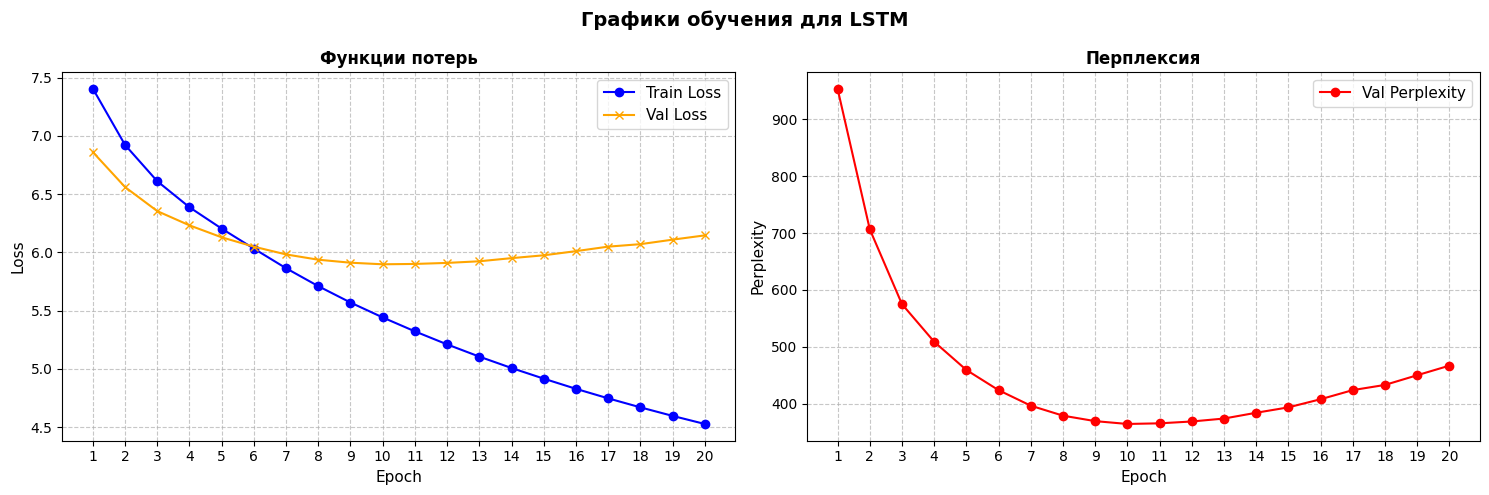

In [8]:
"""
Этап 2. Реализация и обучение LSTM
5) Постройте графики обучения.

"""
# 1 строка, 2 колонки
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, EPOCHS + 1)

# кривые функции потерь (Loss)
ax1 = axes[0]
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
ax1.plot(epochs_range, history["val_loss"], label="Val Loss", color="orange", marker="x")

ax1.set_title("Функции потерь", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Loss", fontsize=11)
ax1.set_xticks(epochs_range)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.7)


# перплексия (Perplexity)
ax2 = axes[1]
ax2.plot(epochs_range, history["val_perplexity"], label="Val Perplexity", color="red", marker="o")

ax2.set_title("Перплексия", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Perplexity", fontsize=11)
ax2.set_xticks(epochs_range)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.7)

# Общий супер-заголовок для всей визуализации
fig.suptitle("Графики обучения для LSTM", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


In [9]:
"""
Этап 3. Эксперимент: GRU vs LSTM
1) Замените LSTM на GRU в модели.
2) Обучите GRU-модель с теми же гиперпараметрами.

"""

# остальное сверху
RNN_TYPE = "GRU"

model_gru = RNNLanguageModel(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    rnn_type=RNN_TYPE
).to(device)

optimizer_gru = optim.AdamW(model_gru.parameters(), lr=LR, weight_decay=0.01)

# история обучения
history_gru = {
    "train_loss": [],
    "val_loss": [],
    "val_perplexity": [],
    "epoch_time": []
}


# цикл обучения
for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    # обучение
    train_loss = epoch_train_model(model_gru, train_loader, criterion, optimizer_gru, device, GRAD_CLIP)
    # валидация
    val_loss = evaluate_model(model_gru, val_loader, criterion, device)
    # перплексия = e^Loss с максимальным ограничением от ошибки
    val_perplexity = math.exp(min(val_loss, 709))

    epoch_time = time.time() - start_time

    # история
    history_gru["train_loss"].append(train_loss)
    history_gru["val_loss"].append(val_loss)
    history_gru["val_perplexity"].append(val_perplexity)
    history_gru["epoch_time"].append(epoch_time)

    # результаты текущей эпохи
    print(
        f"Epoch {epoch}/{EPOCHS} | Время: {epoch_time:.1f}с | " 
        f"Val Loss: {val_loss:.4f} | Val Perplexity: {val_perplexity:.2f}"
    )

# тестовая выборка
test_loss_gru = evaluate_model(model_gru, test_loader, criterion, device)
test_perplexity_gru = math.exp(min(test_loss_gru, 709))
print(f"\nTest Loss: {test_loss_gru:.4f} | Test Perplexity: {test_perplexity_gru:.2f}")

Epoch 1/20 | Время: 470.1с | Val Loss: 6.9696 | Val Perplexity: 1063.77
Epoch 2/20 | Время: 782.3с | Val Loss: 6.3446 | Val Perplexity: 569.40
Epoch 3/20 | Время: 791.3с | Val Loss: 6.0227 | Val Perplexity: 412.67
Epoch 4/20 | Время: 789.4с | Val Loss: 5.8994 | Val Perplexity: 364.81
Epoch 5/20 | Время: 799.1с | Val Loss: 5.8583 | Val Perplexity: 350.13
Epoch 6/20 | Время: 824.6с | Val Loss: 5.8587 | Val Perplexity: 350.28
Epoch 7/20 | Время: 769.4с | Val Loss: 5.8847 | Val Perplexity: 359.50
Epoch 8/20 | Время: 761.7с | Val Loss: 5.9113 | Val Perplexity: 369.19
Epoch 9/20 | Время: 771.6с | Val Loss: 5.9579 | Val Perplexity: 386.81
Epoch 10/20 | Время: 635.2с | Val Loss: 6.0096 | Val Perplexity: 407.31
Epoch 11/20 | Время: 683.9с | Val Loss: 6.0657 | Val Perplexity: 430.83
Epoch 12/20 | Время: 779.4с | Val Loss: 6.1179 | Val Perplexity: 453.93
Epoch 13/20 | Время: 771.3с | Val Loss: 6.1739 | Val Perplexity: 480.08
Epoch 14/20 | Время: 819.4с | Val Loss: 6.2332 | Val Perplexity: 509.37


In [10]:
"""
Этап 3. Эксперимент: GRU vs LSTM
3) Сравните perplexity, количество параметров, время на эпоху.

"""
# test perplexity
print(f"\nLSTM: Test Loss: {test_loss:.4f} | Test Perplexity: {test_perplexity:.2f}")
print(f"GRU: Test Loss: {test_loss_gru:.4f} | Test Perplexity: {test_perplexity_gru:.2f}")

# epoch_time
print(f"\nLSTM epoch_time: MIN: {np.min(history["epoch_time"]):.2f} | MAX: {np.max(history["epoch_time"]):.2f} | AVG: {np.mean(history["epoch_time"]):.2f}")
print(f"GRU epoch_time: MIN: {np.min(history_gru["epoch_time"]):.2f} | MAX: {np.max(history_gru["epoch_time"]):.2f} | AVG: {np.mean(history_gru["epoch_time"]):.2f}")

# подсчёт параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print("\nLSTM param_count:", count_parameters(model))
print(f"GRU param_count:", count_parameters(model_gru))


LSTM: Test Loss: 6.0848 | Test Perplexity: 439.15
GRU: Test Loss: 6.5008 | Test Perplexity: 665.70

LSTM epoch_time: MIN: 357.91 | MAX: 848.67 | AVG: 544.94
GRU epoch_time: MIN: 345.23 | MAX: 836.47 | AVG: 694.34

LSTM param_count: 12126640
GRU param_count: 11896240


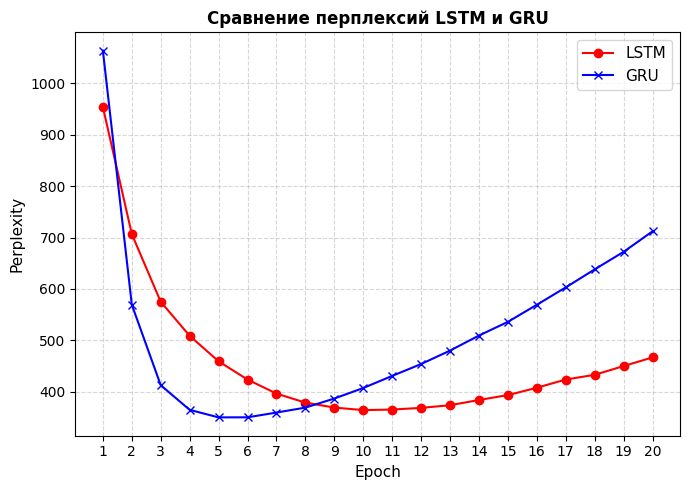

In [11]:

epochs_range = range(1, EPOCHS + 1)

# 1 строка, 1 колонка
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# перплексия 
ax.plot(epochs_range, history["val_perplexity"], label="LSTM", color="red", marker="o")
ax.plot(epochs_range, history_gru["val_perplexity"], label="GRU", color="blue", marker="x")

# атрибуты
ax.set_title("Сравнение перплексий LSTM и GRU", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Perplexity", fontsize=11)

# настройка сетки и шага осей
ax.set_xticks(epochs_range)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [12]:
"""
Этап 4. Оценка distilgpt2
1) Загрузите предобученный distilgpt2 и его токенизатор.
2) Вычислите perplexity distilgpt2 на тестовой выборке.
3) Покажите примеры предсказаний distilgpt2.

"""
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# токенизатор и модель
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model_distilgpt2 = AutoModelForCausalLM.from_pretrained(model_name)
model_distilgpt2.config.loss_type = "ForCausalLMLoss" # от ворнинга
model_distilgpt2 = model_distilgpt2.to(device)

# pad-токен для GPT-2
tokenizer.pad_token = tokenizer.eos_token
model_distilgpt2.config.pad_token_id = model_distilgpt2.config.eos_token_id

# тестовая выборка
model_distilgpt2.eval()

sum_loss = 0
total_tokens = 0

with torch.no_grad():
    for text in test_text_data:
        # токенизация    
        inputs = tokenizer(
            text, 
            return_tensors="pt", 
            truncation=True, 
            max_length=512
        ).to(device)

        # перенос на device
        inputs["labels"] = inputs["input_ids"]
        
        outputs = model_distilgpt2(**inputs)
        loss = outputs.loss
        
        num_tokens = inputs["input_ids"].numel()
        sum_loss += loss.item() * num_tokens
        total_tokens += num_tokens

# тестовый лосс и перплексия
test_loss_distilgpt2 = sum_loss / total_tokens
test_perplexity_distilgpt2 = math.exp(min(test_loss_distilgpt2, 709))

print(f"model_distilgpt2: Test Loss: {test_loss_distilgpt2:.4f} | Test Perplexity: {test_perplexity_distilgpt2:.2f}\n")


# pipeline для генерации
device_id = 0 if device.type == "cuda" else -1

generator = pipeline(
    task="text-generation",
    model=model_distilgpt2,
    tokenizer=tokenizer,
    device=device_id
)

# исходные промпты
prompts = [
    "homarus gammarus known as the european lobster or common lobster is a species of clawed lobster from the eastern atlantic ocean mediterranean sea and parts of the",
    "as with previous valkyira chronicles games valkyria chronicles iii is a tactical role playing",
    "robert boulter is an english film television and theatre actor he had a guest",
]

# генерирация
for prompt in prompts:
    out = generator(
        prompt,
        max_new_tokens=80,
        truncation=True,
        num_return_sequences=1,
        do_sample=True,
        top_p=0.95,
        temperature=0.8,
        pad_token_id=tokenizer.eos_token_id,
        no_repeat_ngram_size=3,
        repetition_penalty=1.2   
    )
    print(f"Промпт:  {prompt}")
    print(f"Ответ:   {out[0]['generated_text']}\n{'-'*10}")

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
Device set to use cpu


model_distilgpt2: Test Loss: 4.9970 | Test Perplexity: 147.97

Промпт:  homarus gammarus known as the european lobster or common lobster is a species of clawed lobster from the eastern atlantic ocean mediterranean sea and parts of the
Ответ:   homarus gammarus known as the european lobster or common lobster is a species of clawed lobster from the eastern atlantic ocean mediterranean sea and parts of the Mediterranean that are in part connected by an extensive range. It has long been described as having one "cradle" between two divergent groups, with its red wing-shaped tentacles on both sides pointing towards each other (although this was not always true for all specimens). The lobos tend to be larger than their natural size but have no discolored scales; however, there were many more verte
----------
Промпт:  as with previous valkyira chronicles games valkyria chronicles iii is a tactical role playing
Ответ:   as with previous valkyira chronicles games valkyria chronicles iii is a tac

In [13]:
"""
Этап 5. Сравнение и выводы
1) Соберите результаты всех моделей в таблицу: модель, число параметров, val perplexity, test perplexity, время на эпоху.

"""

total_data = {
    "Модель": ["LSTM", "GRU", "distilgpt2"],
    "Число параметров": [
        f"{count_parameters(model):,}",
        f"{count_parameters(model_gru):,}",
        f"{count_parameters(model_distilgpt2):,}"
    ],
    "Val Perplexity": [
        f"{history['val_perplexity'][-1]:.2f}",
        f"{history_gru['val_perplexity'][-1]:.2f}",
        "—"
    ],
    "Test Perplexity": [
        f"{test_perplexity:.2f}",
        f"{test_perplexity_gru:.2f}",
        f"{test_perplexity_distilgpt2:.2f}"
    ],
    "Время на эпоху": [
        f"{np.mean(history["epoch_time"]):.1f} сек.",
        f"{np.mean(history_gru["epoch_time"]):.1f} сек.", "—"
    ]
}

df_results = pd.DataFrame(total_data)
df_results.index = df_results.index + 1

display(df_results)

,Модель,Число параметров,Val Perplexity,Test Perplexity,Время на эпоху
1,LSTM,"12,126,640",466.87,439.15,544.9 сек.
2,GRU,"11,896,240",712.19,665.70,694.3 сек.
3,distilgpt2,"81,912,576",—,147.97,—


In [14]:
"""
Этап 5. Сравнение и выводы
2) Покажите примеры предсказаний всех моделей на одних и тех же контекстах (5–10 примеров).
3) Сделайте выводы: какая модель лучше и почему. Дайте рекомендации для продакт-менеджера

"""

def generator_text_rnn(model, input_text, max_new_tokens=80, temperature=0.8):
    model.eval()

    # текст в очищенный ID токенов
    input_ids = word_to_ids(clean_string(input_text))

    with torch.no_grad():
        for _ in range(max_new_tokens):

            x_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)

            outputs = model(x_tensor)

            # логиты последнего слова
            next_token_outputs = outputs[0, -1, :] / temperature

            # вероятности
            probs = torch.softmax(next_token_outputs, dim=-1)
            
            # новое слово (ID)
            next_token = torch.multinomial(probs, num_samples=1).item()

            input_ids.append(next_token)

    # итоговый список ID в текст
    return ids_to_word(input_ids)



# контекст
prompts = [
    "DNA, or deoxyribonucleic acid, is the hereditary material in humans and",
    "Deep learning is a subset of machine learning, which is essentially",
    "When water reaches its boiling point at sea level, it begins to turn into",
    "Deep in the uncharted forest, a hidden door was discovered beneath the",
    "The company successfully raised fifty million dollars in the latest funding round to expand its"
]



# генерирация
for prompt in prompts:

    # LSTM
    out_lstm = generator_text_rnn(model, prompt, max_new_tokens=50, temperature=0.8)

    # GRU
    out_gru = generator_text_rnn(model_gru, prompt, max_new_tokens=50, temperature=0.8)

    # distilgpt2
    out_distilgpt2 = generator(
        prompt,
        max_new_tokens=50,
        truncation=True,
        num_return_sequences=1,
        do_sample=True,
        top_p=0.95,
        temperature=0.8,
        pad_token_id=tokenizer.eos_token_id,
        no_repeat_ngram_size=3,
        repetition_penalty=1.2 
    )
    print(f"Промпт:  {prompt}")
    print(f"Ответ LSTM:   {out_lstm}")
    print(f"Ответ GRU:   {out_gru}")
    print(f"Ответ distilgpt2:   {out_distilgpt2[0]['generated_text']}\n{'-'*10}")



Промпт:  DNA, or deoxyribonucleic acid, is the hereditary material in humans and
Ответ LSTM:   dna or <unk> acid is the hereditary material in humans and <unk> with juveniles and common starlings are used microscopically two dimensional reactions and other gregarious may be used to encompass punctuation <unk> with the soil of the type of dressings are commonly mediated to have a hydrophobic grey race the single is followed by a barometer of a small star
Ответ GRU:   dna or <unk> acid is the hereditary material in humans and locals to establish the <unk> community blocking of god of shiva and the other deities in the writings of parvati the <unk> shiva has a distinct goods as official the annals of the egyptians until this cave djedkare is attested from the kings of shiva to shiva and parvati which
Ответ distilgpt2:   DNA, or deoxyribonucleic acid, is the hereditary material in humans and other mammals.
The most common types of animal are leopards (Parchina) but no one has ever been see

In [15]:
"""
Этап 5. Сравнение и выводы
3) Сделайте выводы: какая модель лучше и почему. Дайте рекомендации для продакт-менеджера
"""
"""
Тут будут выводы
"""




'\nТут будут выводы\n'